In [5]:
#Task 1 - Data Exploration Analysis & Prediction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [6]:
df = pd.read_csv("students.txt")

In [7]:
print("First 5 rows:")
print(df.head()) #first 5 rows

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [8]:
print("\nShape:", df.shape)
print("\nData types:")
print(df.dtypes) #shape and data type


Shape: (15, 9)

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [9]:
print("\nSummary statistics:")
print(df.describe()) #print mean, min, max, std


Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               

In [10]:
print("\nPass/Fail counts:")
print(df['passed'].value_counts()) #count of passed/failed students

subject_cols = ['math', 'science', 'english', 'history', 'pe'] #average score per subject for pass vs fail

print("\nAverage scores per subject for Passing students:")
print(df[df['passed']==1][subject_cols].mean())

print("\nAverage scores per subject for Failing students:")
print(df[df['passed']==0][subject_cols].mean())



Pass/Fail counts:
passed
1    9
0    6
Name: count, dtype: int64

Average scores per subject for Passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores per subject for Failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [11]:
top_student = df.loc[df[subject_cols].mean(axis=1).idxmax(), 'name']
print("\nStudent with highest average score:", top_student)


Student with highest average score: Diana


In [12]:
#Task 2 - Data Visualization with Matplotlib

df['avg_score'] = df[subject_cols].mean(axis=1) #create avg_score column

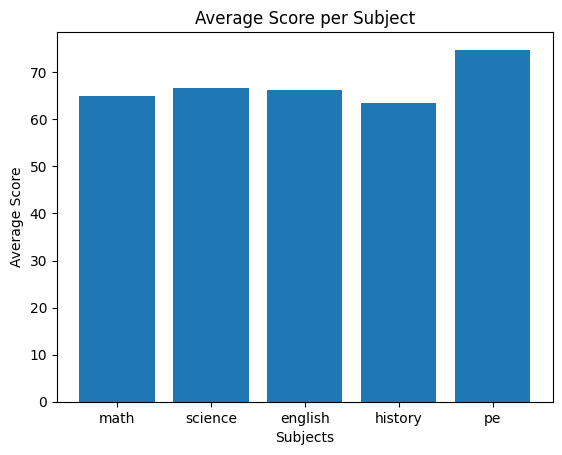

In [13]:
#Bar Chart - Average score per subject
avg_scores = df[subject_cols].mean()
plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

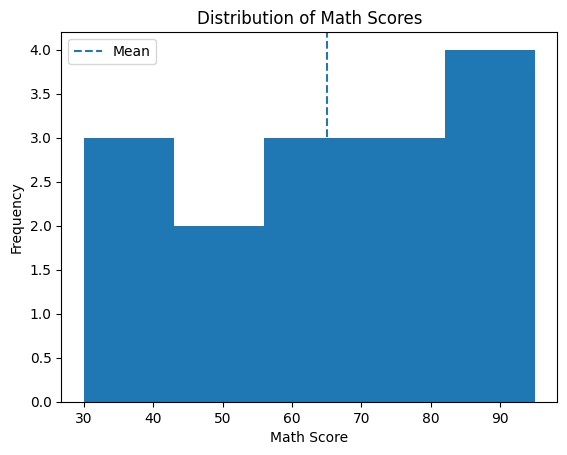

In [14]:
#Histogram - Math scores
plt.figure()
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed', label="Mean")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()

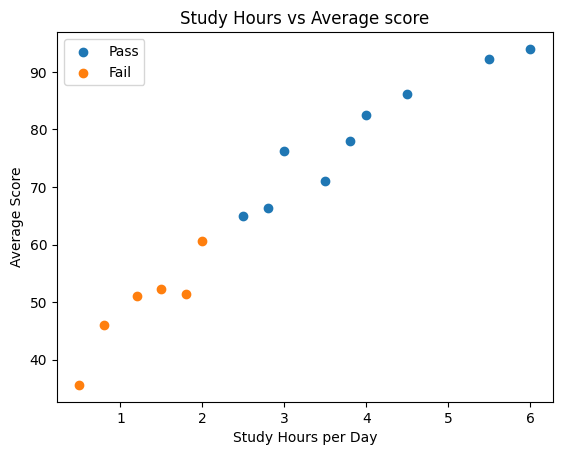

In [15]:
#Scatter Plot - Study hours vs avg_score
plt.figure()
plt.scatter(df[df['passed']==1]['study_hours_per_day'],
            df[df['passed']==1]['avg_score'], label="Pass")
plt.scatter(df[df['passed']==0]['study_hours_per_day'],
            df[df['passed']==0]['avg_score'], label="Fail")

plt.title("Study Hours vs Average score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_12460\439715329.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


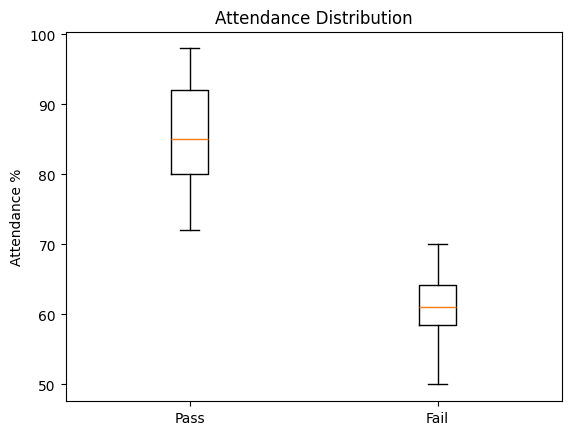

In [16]:
#Box Plot - Attendance
pass_attendance = df[df['passed']==1]['attendance_pct'].tolist()
fail_attendance = df[df['passed']==0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()

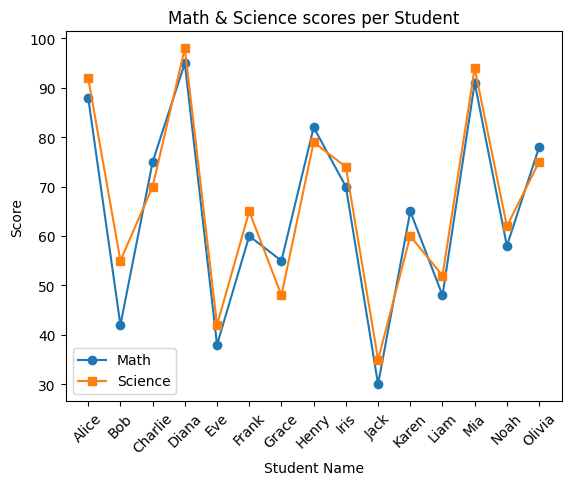

In [17]:
#Line Plot - Math & Science scores
plt.figure()
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')
plt.xticks(rotation=45)
plt.title("Math & Science scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

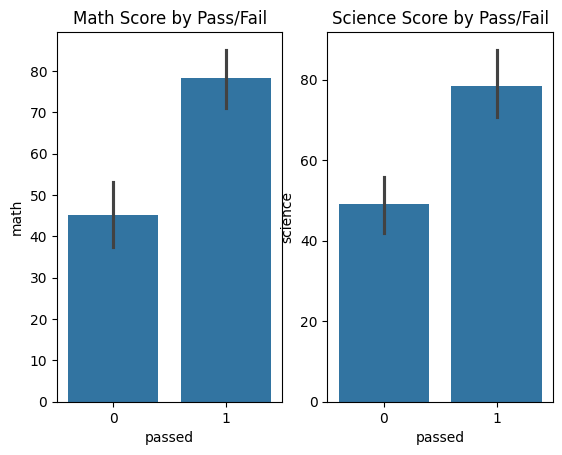

In [18]:
#Task 3 - Data Visualization(Seaborn)

#Seaborn Bar Plot

fig, (ax1, ax2) = plt.subplots(1,2)

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math Score by Pass/Fail")

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science Score by Pass/Fail")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

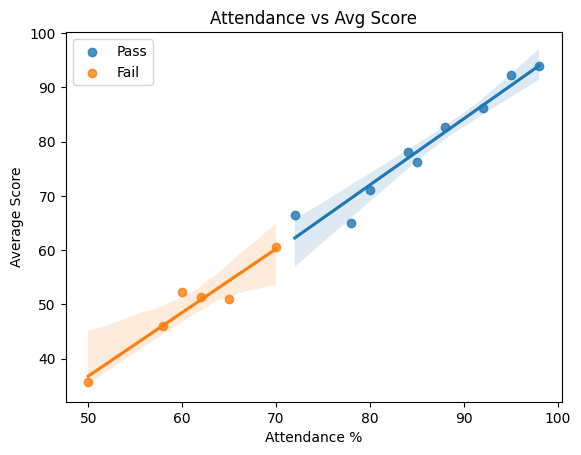

In [19]:
# Seaborn Scatter + Regression

plt.figure()
sns.regplot(data=df[df['passed']==1],
            x='attendance_pct', y='avg_score', label='Pass')
sns.regplot(data=df[df['passed']==0],
            x='attendance_pct', y='avg_score', label='Fail')

plt.title("Attendance vs Avg Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [ ]:
#Comment:
#Seaborn is easier for statistical plots and regression lines.
#Matplotlib gives more control but needs more code.

In [ ]:
#Task 4 - Machine Learning
#Step 1 - Prepare data

X = df[subject_cols + ['attendance_pct', 'study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [22]:
#step 2 - Train Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("\nTraining Accuracy:", model.score(X_train_scaled, y_train))


Training Accuracy: 1.0


In [23]:
#step - 3 Evaluate

y_pred = model.predict(X_test_scaled)
print("Test Accuracy:", model.score(X_test_scaled, y_test))

print("\nPredictions:")
for idx in X_test.index:
    name = df.loc[idx, 'name']
    actual = y_test.loc[idx]
    pred = y_pred[list(X_test.index).index(idx)]
    result = '✅' if actual == pred else "❌"
    print(f"{name} | Actual: {actual}, Predicted: {pred} {result}")


Test Accuracy: 1.0

Predictions:
Jack | Actual: 0, Predicted: 0 ✅
Liam | Actual: 0, Predicted: 0 ✅
Alice | Actual: 1, Predicted: 1 ✅



Feature Importance:
english : 0.813
attendance_pct : 0.522
study_hours_per_day : 0.484
pe : 0.475
math : 0.438
science : 0.323
history : 0.263


<function matplotlib.pyplot.show(close=None, block=None)>

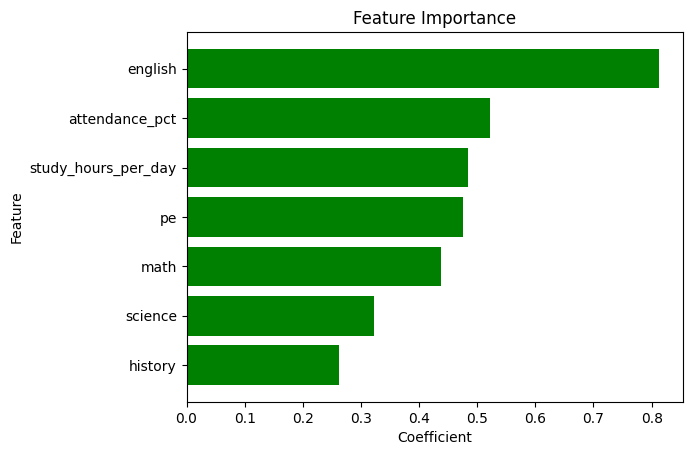

In [25]:
#Step 4 - Feature Importance
coefs = model.coef_[0]
features = subject_cols + ['attendance_pct', 'study_hours_per_day']

importance = sorted(zip(features, coefs), key=lambda x: abs(x[1]), reverse = True)

print("\nFeature Importance:")
for f, c in importance:
    print(f, ":", round(c,3))

#Plot feature importance
plt.figure()
colors = ['green' if c > 0 else 'red' for _, c in importance]

plt.barh([f for f,_ in importance],
         [c for _,c in importance],
         color=colors)

plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show

In [ ]:
#Step 5 - New student prediction

new_student = [[75, 70, 68, 65, 80, 82, 3.2]],  # order must match feature columns

new_scaled = scaler.transform(new_student)
prediction = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)[0]

print("\nNew Student Prediction:", "Pass" if prediction==1 else "Fail")
print("Probability - Pass:", round(prob[1],2), "Fail:", round(prob[0],2))


New Student Prediction: Pass
Probability - Pass: 0.91 Fail: 0.09


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
